# Homework 2

In [1]:
import numpy as np
import pandas as pd

Firstly, we import our data. For this exercise, we shall be using the 2026 Car Fuel Efficiency dataset. 

In [2]:
car_fuel_efficiency_2026 = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

In [3]:
!wget $car_fuel_efficiency_2026

--2026-09-24 10:46:52--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv.4’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.007s  

2026-09-24 10:46:53 (91.9 MB/s) - ‘car_fuel_efficiency_2026.csv.4’ saved [635180/635180]



Next, we read the csv file.

## Data preparation

In [4]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')

In [5]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


Our goal in this homework is to predict the car fuel efficiency (`fuel_efficiency_mpg`). To do that, we first do a little bit of cleaning. The first bit of cleaning we do is to standardise the column entries.

In [6]:
df.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [7]:
df.dtypes == 'str'

model_year             False
origin                  True
fuel_type               True
drivetrain              True
num_doors              False
engine_displacement    False
num_cylinders          False
horsepower             False
vehicle_weight         False
acceleration           False
fuel_efficiency_mpg    False
dtype: bool

In [8]:
df.dtypes[df.dtypes == 'str'] #Returns only true values

origin        str
fuel_type     str
drivetrain    str
dtype: object

In [9]:
strings = list(df.dtypes[df.dtypes == 'str'].index)
strings

['origin', 'fuel_type', 'drivetrain']

In [10]:
 for col in strings:
     df[col] = df[col].str.lower().str.replace(' ', '_').str.replace('-', '_')

In [11]:
df

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,europe,gasoline,front_wheel_drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,europe,diesel,front_wheel_drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,asia,gasoline,front_wheel_drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,europe,gasoline,front_wheel_drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,usa,diesel,front_wheel_drive,3,2580,7,304.0,4510,17.5,31.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2005,usa,gasoline,all_wheel_drive,4,2470,6,271.0,4690,18.9,27.4
9996,1993,asia,gasoline,all_wheel_drive,2,2300,6,244.0,4370,19.0,30.0
9997,2014,usa,gasoline,all_wheel_drive,3,2480,6,267.0,4590,18.4,28.1
9998,2004,usa,hybrid,rear_wheel_drive,5,2180,6,270.0,4450,20.9,32.2


We have now written thhe entries of the dataframe in a consistent manner.

## EDA

For the following exercise, we use only the following columns: `engine_displacement`, `horsepower`, `vehicle_weight`, `model_year`, and `fuel_efficiency_mpg`.

In [12]:
df = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


Now, we check the distribution of 

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib  inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

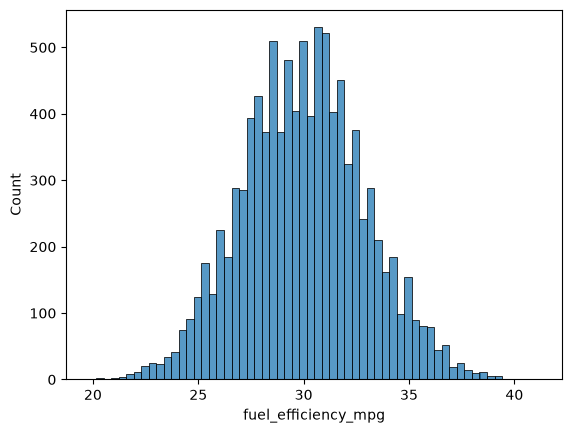

In [14]:
sns.histplot(df.fuel_efficiency_mpg)

From the graph above, the distribution of fuel efficiency is not long tailed.

## Q1
There's one column with missing values. What is it?

In [15]:
df.isnull().any()

engine_displacement    False
horsepower              True
vehicle_weight         False
model_year             False
fuel_efficiency_mpg    False
dtype: bool

In [16]:
print(f"The only column with the missing values is: {list(df.columns[df.isnull().any()])[0]}")

The only column with the missing values is: horsepower


## Q2
What is the median for the variable `horsepower`?

In [17]:
horsepower_median = df['horsepower'].median()

In [18]:
print(f"The median for the variable horsepower is {horsepower_median}")

The median for the variable horsepower is 254.0


## Preparations and splitting up of the dataframe

To train our model, we split it in to Training, Validation and Test datasets in the proportion $60\%$, $20\%$ and $20\%$ respectively.

In [19]:
n = len(df) #to check the lenght of the dataframe
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42) #To ensure reproducibility
idx = np.arange(n) #Put n items in a list
np.random.shuffle(idx) #Shuffle idx randomly

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train: n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [20]:
df_train = df_train.reset_index(drop=True)
df_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,1900,239.0,3790,2015,32.5
1,2000,224.0,4380,1992,29.1
2,2330,286.0,4090,2022,34.1
3,2300,NaN,4150,1997,30.6
4,2340,269.0,4400,2001,30.7
...,...,...,...,...,...
5995,2280,242.0,4590,2018,29.8
5996,2300,NaN,4240,1984,25.1
5997,2240,255.0,4190,1989,27.7
5998,2430,254.0,4280,2020,31.6


In [21]:
df_val= df_val.reset_index(drop=True)
df_test= df_test.reset_index(drop=True)

In [22]:
y_train = df_train.fuel_efficiency_mpg.values
y_train

array([32.5, 29.1, 34.1, ..., 27.7, 31.6, 28. ], shape=(6000,))

In [23]:
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [24]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

df_train[base]

,engine_displacement,horsepower,vehicle_weight,model_year
0,1900,239.0,3790,2015
1,2000,224.0,4380,1992
2,2330,286.0,4090,2022
3,2300,NaN,4150,1997
4,2340,269.0,4400,2001
...,...,...,...,...
5995,2280,242.0,4590,2018
5996,2300,NaN,4240,1984
5997,2240,255.0,4190,1989
5998,2430,254.0,4280,2020


In [25]:
df_val[base]

,engine_displacement,horsepower,vehicle_weight,model_year
0,2240,265.0,3990,2004
1,2390,259.0,4770,2019
2,2360,265.0,4320,2018
3,2430,279.0,4430,2008
4,2220,249.0,4030,1999
...,...,...,...,...
1995,1980,229.0,4140,2020
1996,2590,263.0,4630,1989
1997,2390,264.0,4550,2017
1998,2330,244.0,4440,2014


Next, we deal with the missing values.

### Analysis replacing missing values by 0

In [26]:
#Here, we replace all the missing values in the horsepower column with 0
X_train = df_train[base].fillna(0).values

In [27]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    
    return w_full[0], w_full[1:]

In [28]:
train_linear_regression(X_train, y_train)

(np.float64(-153.88496188223104),
 array([-1.51505520e-03, -4.74024794e-06, -3.95418397e-03,  1.02146785e-01]))

In [29]:
w0 = train_linear_regression(X_train, y_train)[0]
w = train_linear_regression(X_train, y_train)[1]

In [30]:
#Now, let us apply the model we just trained to the dateset

y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

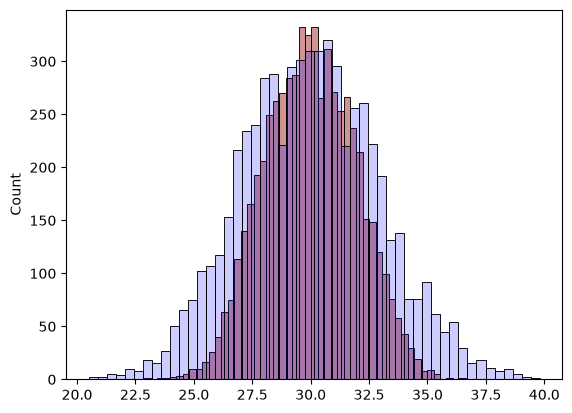

In [31]:
sns.histplot(y_pred, color= 'brown', alpha= 0.5, bins = 50) #alpha is the parameter that controls how transparent the colours are
sns.histplot(y_train, color= 'blue', alpha = 0.2, bins = 50)

#### Validating the model

In [32]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [33]:
def prepare_X(df):
    X = df[base].fillna(0).values
    return X

In [34]:
X_train = prepare_X(df_train[base])
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val[base])
y_pred = w0 + X_val.dot(w)

round(rmse(y_val, y_pred), 3)

np.float64(2.205)

### Analysis replacing missing values by the mean

In [35]:
horsepower_mean = df_train[base].horsepower.mean()
horsepower_mean

np.float64(254.46338337605272)

In [36]:
#Here, we replace all the missing values in the horsepower column with its mean
X_train = df_train[base].fillna(horsepower_mean).values

In [37]:
train_linear_regression(X_train, y_train)
w0,  w = train_linear_regression(X_train, y_train)

In [38]:
w0, w

(np.float64(-153.29645639182718),
 array([-0.00102386, -0.00648622, -0.00388828,  0.10197897]))

In [39]:
#Now, let us apply the model we just trained to the dateset

y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

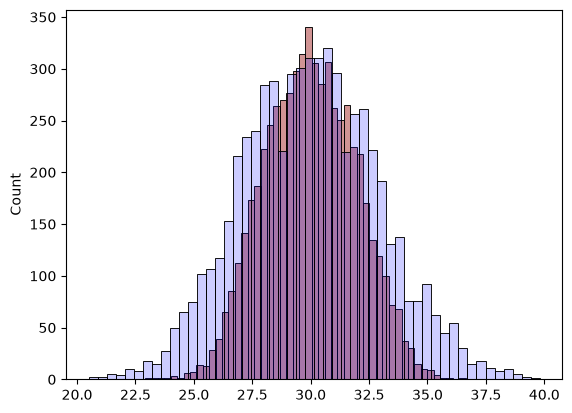

In [40]:
sns.histplot(y_pred, color= 'brown', alpha= 0.5, bins = 50) #alpha is the parameter that controls how transparent the colours are
sns.histplot(y_train, color= 'blue', alpha = 0.2, bins = 50)

#### Validating the model

In [41]:
def prepare_X(df):
    X = df[base].fillna(horsepower_mean).values
    return X

In [42]:
X_train = prepare_X(df_train[base])
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val[base])
y_pred = w0 + X_val.dot(w)

round(rmse(y_val, y_pred), 3)

np.float64(2.202)

### Q3
Between replacing null values in the `horsepower` column by zeros or the mean, which option gives a better RMSE?

A3. From both rmse scores, we see that the option with the mean gives a slightly better value.

### Regularization

For this exercise, we fill the null values with 0.

In [43]:
def train_linear_regression_reg(X, y, r=0.01):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    
    return w_full[0], w_full[1:]

In [44]:
def prepare_X(df):
    X = df[base].fillna(0).values
    return X

In [45]:
X_train = prepare_X(df_train[base])
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X(df_val[base])
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(2.205827616672006)

We try to choose values for $r$ and check which one gives the best value for $RMSE$.

In [46]:
for r in [0.0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val[base])
    y_pred = w0 + X_val.dot(w)

    score = rmse(y_val, y_pred)
    score = round(score, 4)
    print(r, w0, score)

0.0 -153.88496188223104 2.2053
0.01 -148.3092124404723 2.2058
0.1 -111.83871039307081 2.2241
1 -32.331865964969374 2.3492
5 -7.772852209978469 2.4094
10 -3.987116416019025 2.4195
100 -0.4082196488463344 2.4292


### Q4
Which gives the best RMSE?

A4. From the above, we see that $r = 0$ gives the best RMSE.

### Using a different seed value

In [47]:
n = len(df) #to check the lenght of the dataframe
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

scores = []

for s in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    np.random.seed(s) #To ensure reproducibility
    idx = np.arange(n) #Put n items in a list
    
    np.random.shuffle(idx) #Shuffle idx randomly

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train: n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    df_train = df_train.reset_index(drop=True)
    df_val= df_val.reset_index(drop=True)
    df_test= df_test.reset_index(drop=True)

    #y_values
 
    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    #Here, we replace all the missing values in the horsepower column with 0
    X_train = df_train[base].fillna(0).values

    def train_linear_regression(X, y):
        ones = np.ones(X.shape[0])
        X = np.column_stack([ones, X])
        XTX = X.T.dot(X)
        XTX_inv = np.linalg.inv(XTX)
        w_full = XTX_inv.dot(X.T).dot(y)
    
        
        return w_full[0], w_full[1:]

    def prepare_X(df):
        X = df[base].fillna(0).values
        return X


    def rmse(y, y_pred):
        se = (y - y_pred) ** 2
        mse = se.mean()
        return np.sqrt(mse)


    train_linear_regression(X_train, y_train)

    w0, w = train_linear_regression(X_train, y_train)
    
    X_val = prepare_X(df_val[base])
    y_pred = w0 + X_val.dot(w)
    
    score = rmse(y_val, y_pred)
    scores.append(score)


std = np.std(scores)

print(f"The standard deviation of the rmse using different seed values is: {round(std, 3)}")

The standard deviation of the rmse using different seed values is: 0.029


Since the standard deviation is low, it shows that our model is _stable_.

Next, we use the values for $s=9$ for the model.

In [48]:
# Now we want to parse both dataframes
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop = True) # we reset the index in tthe above joined dataframes
df_full_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2320,246.0,4100,2014,32.5
1,2230,252.0,4250,1998,33.2
2,2700,276.0,4490,2008,32.4
3,2220,269.0,4060,2004,29.9
4,2370,NaN,4690,1979,26.4
...,...,...,...,...,...
7995,2690,324.0,4510,2023,35.7
7996,1920,190.0,4000,1998,30.8
7997,1800,225.0,3980,1994,29.1
7998,1970,232.0,3560,2009,32.2


In [49]:
X_full_train = prepare_X(df_full_train[base])
X_full_train

array([[2320.,  246., 4100., 2014.],
       [2230.,  252., 4250., 1998.],
       [2700.,  276., 4490., 2008.],
       ...,
       [1800.,  225., 3980., 1994.],
       [1970.,  232., 3560., 2009.],
       [2180.,  254., 3970., 2018.]], shape=(8000, 4))

In [50]:
np.isnan(X_full_train).sum()

np.int64(0)

In [51]:
y_full_train = df_full_train['fuel_efficiency_mpg'].values
y_full_train

array([32.5, 33.2, 32.4, ..., 29.1, 32.2, 35.6], shape=(8000,))

In [52]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

Now, we prepare the test dataset

In [53]:
X_test = prepare_X(df_test[base])
y_pred = w0 + X_test.dot(w)

score = rmse(y_test, y_pred)

score

np.float64(2.2358277471917636)

In [55]:
print(f"The RMSE on the test dataset is: {round(score, 3)}")

The RMSE on the test dataset is: 2.236
